# Customer Churn Analysis

## Milestone 2 — Customer Churn Early-Warning Model

Customer churn occurs when existing customers stop using a company's products or services. This analysis investigates whether customer behaviour can be used to identify customers at risk of churning early enough for the business to take retention action.

**Business question:** Can we identify customers who are likely to churn using the information already available about them?

## 1. Import Libraries

We import the libraries required for data manipulation, numerical analysis and visualisation. Additional machine-learning libraries will be introduced when we reach the modelling stage.

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 2. Load the Dataset

We load the customer churn dataset into Pandas and create a working copy for the analysis. Keeping the original DataFrame unchanged gives us a clean reference point if the data is transformed later.

In [ ]:
DATA_PATH = Path('../dataset/milestone-2-customer-churn.csv')

df = pd.read_csv(DATA_PATH)
data = df.copy()

data.head(20)

,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,DaysSinceLastOrder,SupportTicketsFiled,Churned
0,7,34.12,7,8,2,0
1,45,23.38,3,57,1,0
2,24,94.56,7,37,1,0
3,39,46.34,7,0,0,0
4,3,39.04,3,41,2,0
5,38,48.05,7,14,0,0
6,22,51.20,8,7,0,1
7,49,45.07,4,39,1,0
8,45,48.48,4,60,0,0
9,44,54.75,9,6,1,0


## 3. Initial Dataset Inspection

We examine the dataset's dimensions, columns and data types, followed by checks for missing values and duplicate records. This establishes whether there are any basic data-quality issues that need to be addressed before analysis.

### 3.1 Dataset Structure

We identify the number of customer records and variables available for the analysis. The variables will later be separated into predictors and the target variable, `Churned`.

In [132]:
print(f'Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns')

print('\nColumn names:')
print(data.columns.tolist())

Dataset shape: 20,000 rows × 6 columns

Column names:
['MonthsActive', 'AvgOrderValue', 'NumOrdersLastQuarter', 'DaysSinceLastOrder', 'SupportTicketsFiled', 'Churned']


### 3.2 Data Types

We check the data types of each variable to determine whether any conversion, encoding or other preparation will be required before modelling.

In [133]:
data.dtypes.to_frame(name='dtype')

,dtype
MonthsActive,int64
AvgOrderValue,float64
NumOrdersLastQuarter,int64
DaysSinceLastOrder,int64
SupportTicketsFiled,int64
Churned,int64


### 3.3 Missing Values and Duplicates

Missing and duplicate records can affect both exploratory analysis and model performance. We check for both conditions before proceeding.

In [134]:
print('Missing values:')
display(data.isna().sum().to_frame(name='missing_values'))

print(f'Duplicate rows: {data.duplicated().sum():,}')

Missing values:


,missing_values
MonthsActive,0
AvgOrderValue,0
NumOrdersLastQuarter,0
DaysSinceLastOrder,0
SupportTicketsFiled,0
Churned,0


Duplicate rows: 0


## 4. Understand the Target Variable

`Churned` is the target variable we want our models to predict, where `0` represents a customer who did not churn and `1` represents a customer who churned. Before modelling, we need to understand how these two classes are distributed.

### 4.1 Churn Distribution

We calculate the number and percentage of churned and non-churned customers. This will show whether the target is balanced and help determine how we should evaluate our models.

In [135]:
target_counts = data['Churned'].value_counts().sort_index()
target_percentages = data['Churned'].value_counts(normalize=True).sort_index().mul(100)

target_summary = pd.DataFrame({
    'Customers': target_counts,
    'Percentage': target_percentages
})

target_summary.index = ['Non-churned (0)', 'Churned (1)']
target_summary

,Customers,Percentage
Non-churned (0),18433,92.16
Churned (1),1567,7.83


### 4.2 Visualising Churn

A simple chart makes the distribution of churn easier to interpret and provides an early indication of whether accuracy could be misleading.

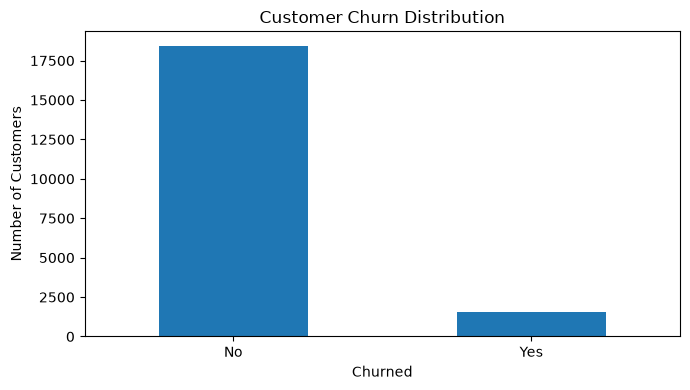

In [136]:
plt.figure(figsize=(7, 4))
data['Churned'].value_counts().sort_index().plot(kind='bar')
plt.title('Customer Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

### 4.3 Why Class Imbalance Matters

If churn represents only a small proportion of customers, a model can achieve high accuracy simply by predicting that most customers will not churn. Therefore, later evaluation will need to consider metrics such as **precision, recall and F1-score**, rather than accuracy alone.

## 5. Descriptive Statistics

We examine the main statistical characteristics of the customer variables to understand their ranges, typical values and variation. This gives us a baseline before comparing the behaviour of churned and non-churned customers.

In [137]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
MonthsActive,"20,000.00",30.28,17.37,1.00,15.00,30.00,45.00,60.00
AvgOrderValue,"20,000.00",59.19,24.71,11.85,41.62,54.81,71.60,402.35
NumOrdersLastQuarter,"20,000.00",5.01,2.00,1.00,4.00,5.00,6.00,14.00
DaysSinceLastOrder,"20,000.00",19.73,19.59,0.00,6.00,14.00,28.00,229.00
SupportTicketsFiled,"20,000.00",0.50,0.70,0.00,0.00,0.00,1.00,5.00
Churned,"20,000.00",0.08,0.27,0.00,0.00,0.00,0.00,1.00


## 6. Understanding the Customer Features

The five predictors describe different aspects of the customer relationship: tenure, spending, order activity, recency and support interactions. We will investigate whether these characteristics differ between customers who churn and those who remain active.

## 7. Exploratory Analysis

The next stage moves from understanding the dataset to identifying potential **churn signals**. We will compare each feature across churned and non-churned customers and use the findings to guide the modelling stage.

### 7.1 Churn vs. Customer Behaviour

We begin by comparing the main customer characteristics between churned and non-churned customers. This gives us an initial view of whether differences in customer activity, spending, recency and support interactions may be associated with churn.

In [138]:
feature_columns = [
    'MonthsActive',
    'AvgOrderValue',
    'NumOrdersLastQuarter',
    'DaysSinceLastOrder',
    'SupportTicketsFiled'
]
churn_comparison = data.groupby('Churned')[feature_columns].agg(['mean', 'median'])
churn_comparison

MonthsActive        AvgOrderValue        NumOrdersLastQuarter         \
                mean median          mean median                 mean median   
Churned                                                                        
0              30.49  30.00         59.24  54.86                 5.04   5.00   
1              27.83  26.00         58.62  54.05                 4.68   4.00   

        DaysSinceLastOrder        SupportTicketsFiled         
                      mean median                mean median  
Churned                                                       
0                    17.83  13.00                0.48   0.00  
1                    42.13  35.00                0.73   1.00

### 7.2 Initial Observations

The grouped summary provides a first indication of how churned customers differ from non-churned customers.

Particular attention should be paid to variables where the mean and median values differ noticeably between the two groups, as these may represent potential churn signals.

At this stage, we are identifying patterns rather than drawing conclusions. The goal is to understand which customer characteristics appear most different before examining their distributions in more detail.

In [139]:
comparison = (
    data.groupby('Churned')[feature_columns]
        .mean()
        .T
)

comparison.columns = ['Non-churned', 'Churned']

comparison['Difference'] = (
    comparison['Churned']
    - comparison['Non-churned']
)

comparison

,Non-churned,Churned,Difference
MonthsActive,30.49,27.83,-2.66
AvgOrderValue,59.24,58.62,-0.62
NumOrdersLastQuarter,5.04,4.68,-0.37
DaysSinceLastOrder,17.83,42.13,24.30
SupportTicketsFiled,0.48,0.73,0.26


### 7.3 Feature Distributions by Churn Status

The previous comparison showed differences in the average values between churned and non-churned customers. We now examine the distributions of the customer features to see how those differences are spread across the two groups.

This helps us determine whether the observed differences are consistent across customers or driven by a small number of observations.

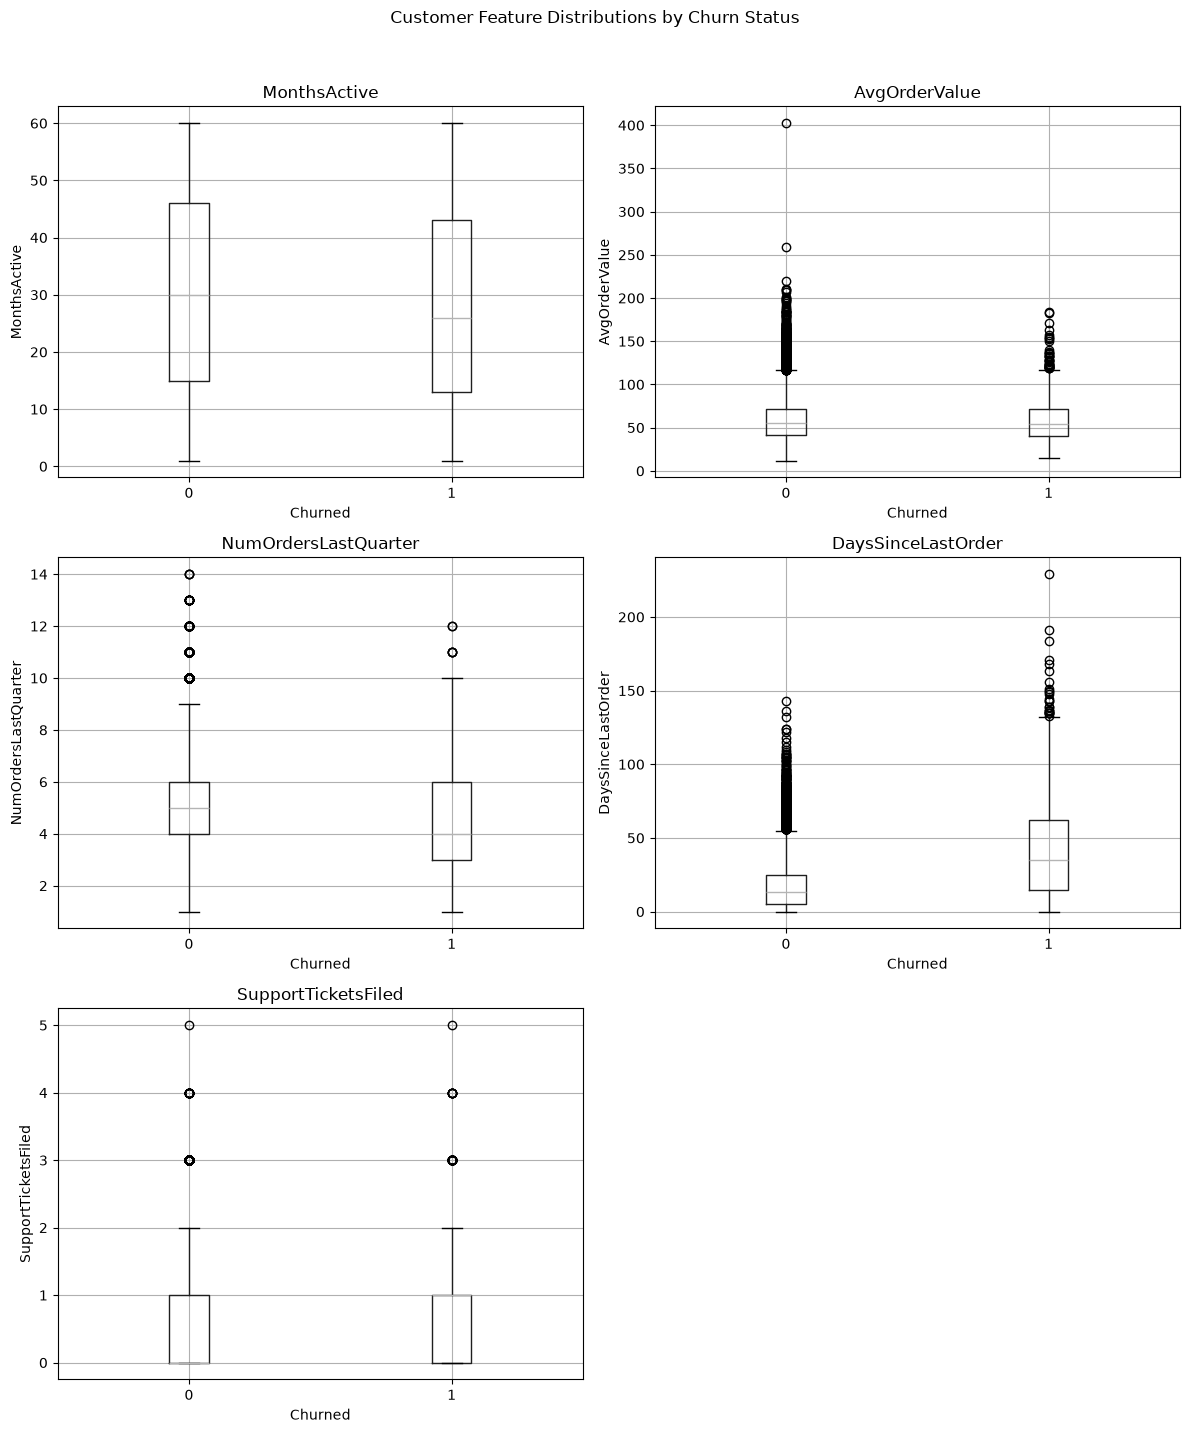

In [140]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for ax, feature in zip(axes.flat, feature_columns):
    data.boxplot(
        column=feature,
        by='Churned',
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel('Churned')
    ax.set_ylabel(feature)

axes[-1, -1].axis('off')

plt.suptitle('Customer Feature Distributions by Churn Status', y=1.02)
plt.tight_layout()
plt.show()

### 7.4 Correlation Between Features

We examine the relationships between the numerical variables to understand whether some customer characteristics move together.

This is useful before modelling because highly related predictors may provide overlapping information, while weaker relationships may represent different aspects of customer behaviour.

In [141]:
correlation_matrix = data[feature_columns + ['Churned']].corr()

correlation_matrix

,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,DaysSinceLastOrder,SupportTicketsFiled,Churned
MonthsActive,1.00,-0.00,0.01,-0.01,0.01,-0.04
AvgOrderValue,-0.00,1.00,0.01,-0.00,-0.00,-0.01
NumOrdersLastQuarter,0.01,0.01,1.00,0.01,-0.00,-0.05
DaysSinceLastOrder,-0.01,-0.00,0.01,1.00,-0.01,0.33
SupportTicketsFiled,0.01,-0.00,-0.00,-0.01,1.00,0.10
Churned,-0.04,-0.01,-0.05,0.33,0.10,1.00


### 7.5 Visualising the Correlations

The correlation matrix gives us the numerical strength and direction of the relationships between the variables. A heatmap provides a visual summary, making it easier to identify stronger relationships and see how the predictors relate to the churn outcome.

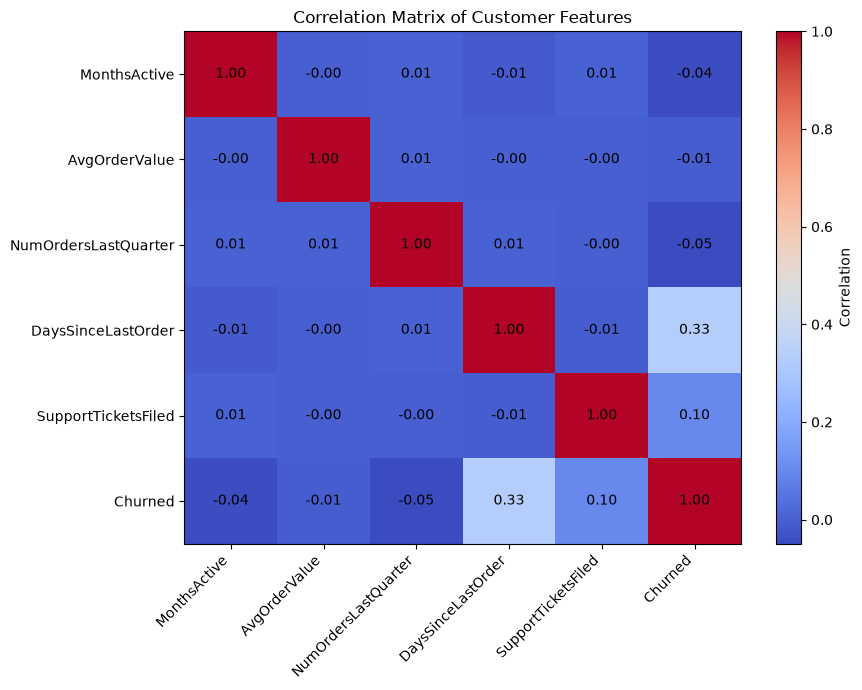

In [142]:
plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Display correlation values inside each cell
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix of Customer Features')

plt.tight_layout()
plt.show()

### 7.6 Initial Exploratory Findings

The exploratory analysis gives us an initial view of which customer characteristics may be associated with churn. We summarise the main differences observed between churned and non-churned customers before moving into model development.

These observations will guide our modelling, but they should be treated as patterns in the data rather than evidence of causation.

In [143]:
# Compare the mean feature values for churned and non-churned customers
exploratory_summary = (
    data.groupby('Churned')[feature_columns]
        .mean()
        .T
)

exploratory_summary.columns = ['Non-churned', 'Churned']

exploratory_summary

,Non-churned,Churned
MonthsActive,30.49,27.83
AvgOrderValue,59.24,58.62
NumOrdersLastQuarter,5.04,4.68
DaysSinceLastOrder,17.83,42.13
SupportTicketsFiled,0.48,0.73


### 7.7 Churn Rate by Customer Behaviour

To examine how churn varies across customer behaviour, customers are grouped into meaningful ranges for each feature and the churn rate is calculated within each group.

The grouping intervals are selected to make behavioural differences easier to interpret, with finer intervals used where the underlying feature shows a stronger relationship with churn.

This allows the analysis to identify behavioural segments with noticeably different levels of churn.

In [144]:
# Create customer behaviour groups for selected numerical features

# 1. Days Since Last Order
recency_bins = [-np.inf, 7, 14, 21, 28, 35, 42, 56, 84, np.inf]

recency_labels = [
    '≤7',
    '8–14',
    '15–21',
    '22–28',
    '29–35',
    '36–42',
    '43–56',
    '57–84',
    '85+'
]

data['RecencyGroup'] = pd.cut(
    data['DaysSinceLastOrder'],
    bins=recency_bins,
    labels=recency_labels
)


# 2. Orders in Last Quarter
order_activity_bins = [-np.inf, 4, 5, 6, np.inf]

order_activity_labels = [
    '≤4',
    '5',
    '6',
    '7+'
]

data['OrderActivityGroup'] = pd.cut(
    data['NumOrdersLastQuarter'],
    bins=order_activity_bins,
    labels=order_activity_labels
)


# 3. Months Active
tenure_bins = [-np.inf, 15, 30, 45, np.inf]

tenure_labels = [
    '≤15',
    '16–30',
    '31–45',
    '46+'
]

data['TenureGroup'] = pd.cut(
    data['MonthsActive'],
    bins=tenure_bins,
    labels=tenure_labels
)


# 4. Average Order Value
order_value_bins = [-np.inf, 41.62, 54.81, 71.605, np.inf]

order_value_labels = [
    '≤41.62',
    '41.63–54.81',
    '54.82–71.61',
    '71.61+'
]

data['OrderValueGroup'] = pd.cut(
    data['AvgOrderValue'],
    bins=order_value_bins,
    labels=order_value_labels
)


# 5. Support Tickets Filed
support_ticket_bins = [-np.inf, 0, 1, 2, np.inf]

support_ticket_labels = [
    '0',
    '1',
    '2',
    '3+'
]

data['SupportGroup'] = pd.cut(
    data['SupportTicketsFiled'],
    bins=support_ticket_bins,
    labels=support_ticket_labels
)

#### Churn Rate Across Customer Behaviour Groups

We now calculate the proportion of customers who churn within each behaviour group. This allows us to compare churn risk across different levels of customer activity rather than relying only on overall averages.

The resulting rates can help identify behavioural segments that may deserve closer attention from the business.

In [145]:
group_columns = {
    'RecencyGroup': 'Churn Rate by Days Since Last Order',
    'OrderActivityGroup': 'Churn Rate by Orders Last Quarter',
    'TenureGroup': 'Churn Rate by Months Active',
    'OrderValueGroup': 'Churn Rate by Average Order Value',
    'SupportGroup': 'Churn Rate by Support Tickets'
}

for column, title in group_columns.items():
    churn_rate = (
        data.groupby(column, observed=True)['Churned']
        .mean()
        .mul(100)
        .round(2)
    )

    print(f'\n{title}')
    display(churn_rate.to_frame('Churn Rate (%)'))


Churn Rate by Days Since Last Order


,Churn Rate (%)
RecencyGroup,
≤7,3.20
8–14,4.31
15–21,5.09
22–28,6.58
29–35,9.54
36–42,12.37
43–56,15.58
57–84,34.16
85+,67.31



Churn Rate by Orders Last Quarter


,Churn Rate (%)
OrderActivityGroup,
≤4,9.09
5,7.90
6,6.46
7+,6.27



Churn Rate by Months Active


,Churn Rate (%)
TenureGroup,
≤15,9.49
16–30,8.34
31–45,6.78
46+,6.66



Churn Rate by Average Order Value


,Churn Rate (%)
OrderValueGroup,
≤41.62,8.46
41.63–54.81,7.65
54.82–71.61,7.39
71.61+,7.84



Churn Rate by Support Tickets


,Churn Rate (%)
SupportGroup,
0,6.11
1,9.23
2,14.01
3+,19.64


### 7.8 Visualising Churn Rate Patterns

The grouped churn rates are visualised to make differences in customer behaviour easier to identify.

The recency chart uses the finer `DaysSinceLastOrder` intervals so that changes in churn rate across increasing periods of inactivity can be observed directly.

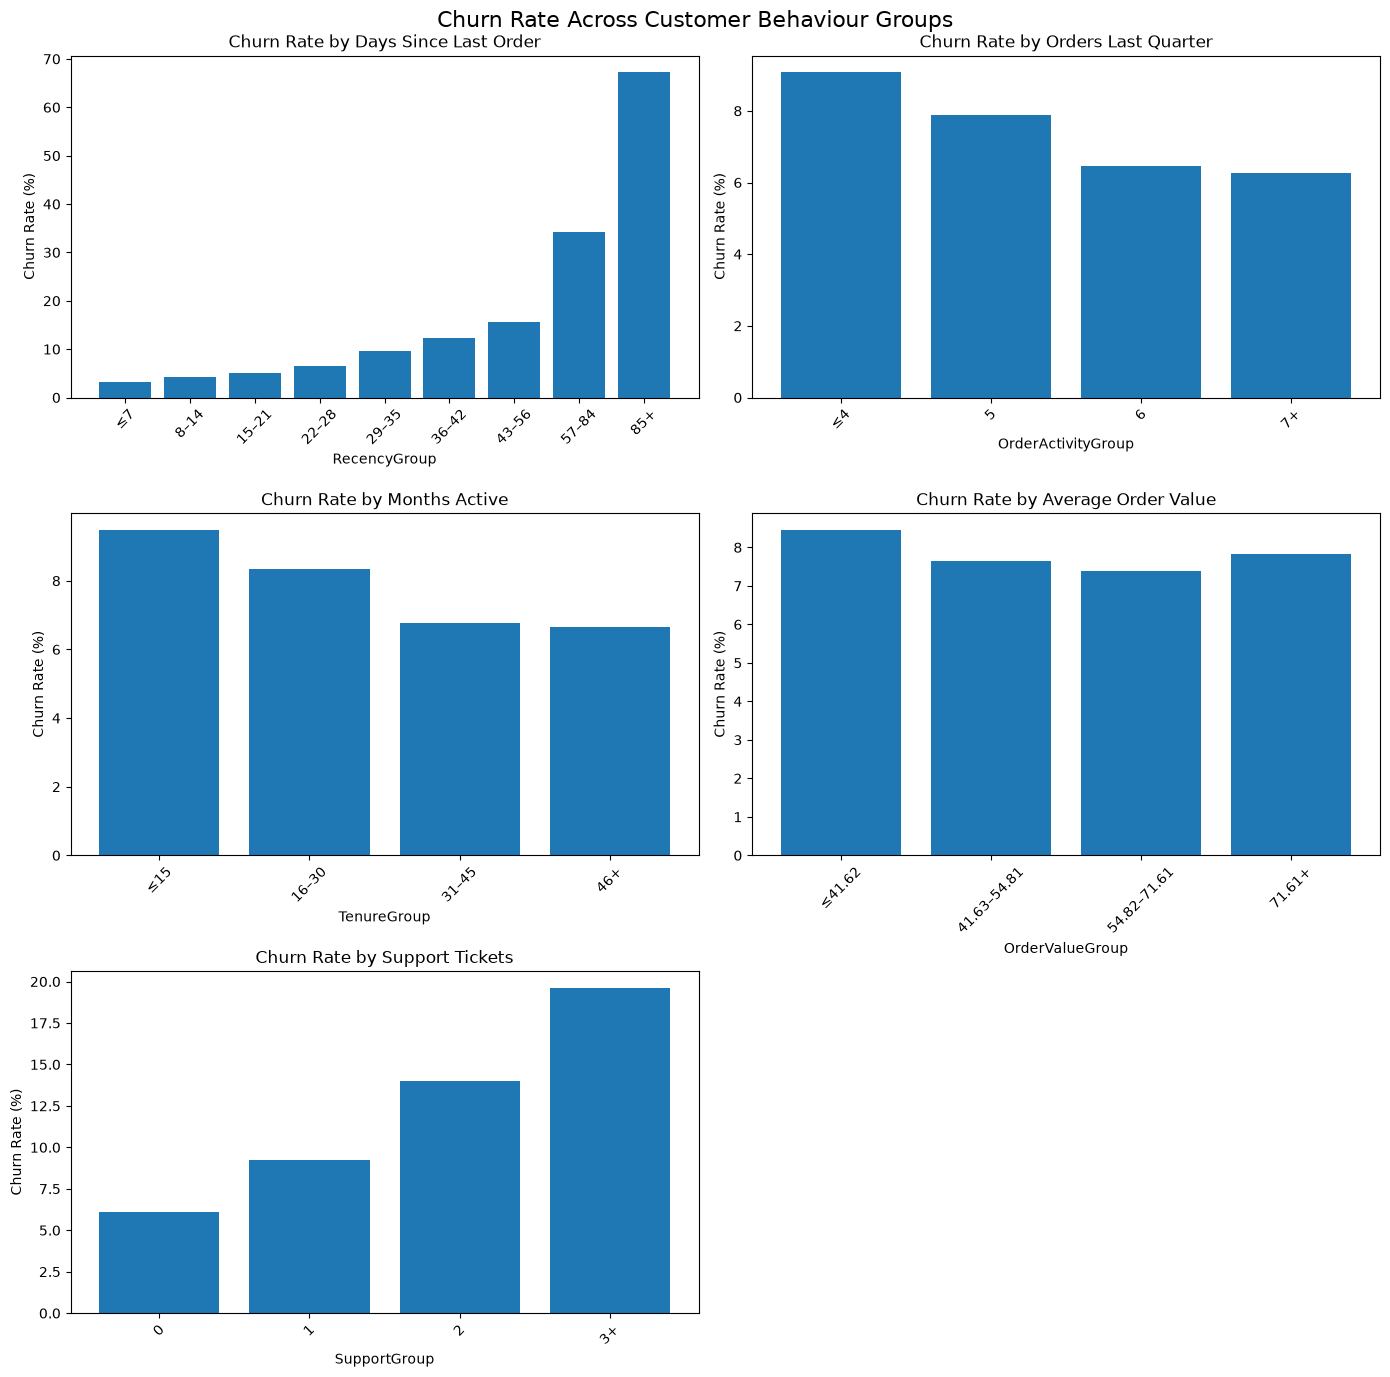

In [146]:
# 7.8 Visualising Churn Rate Patterns

# Calculate churn rates from the customer behaviour groups created in 7.7
churn_rate_groups = {
    'RecencyGroup': 'Churn Rate by Days Since Last Order',
    'OrderActivityGroup': 'Churn Rate by Orders Last Quarter',
    'TenureGroup': 'Churn Rate by Months Active',
    'OrderValueGroup': 'Churn Rate by Average Order Value',
    'SupportGroup': 'Churn Rate by Support Tickets'
}

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for ax, (column, title) in zip(axes.flatten(), churn_rate_groups.items()):

    churn_rate = (
        data.groupby(column, observed=True)['Churned']
        .mean()
        .mul(100)
    )

    ax.bar(
        churn_rate.index.astype(str),
        churn_rate.values
    )

    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=45)

# Remove the unused sixth subplot
axes.flatten()[-1].set_visible(False)

fig.suptitle(
    'Churn Rate Across Customer Behaviour Groups',
    fontsize=16
)

plt.tight_layout()
plt.show()

### 7.9 Outlier and Distribution Check

Before moving into model development, we check the numerical features for unusually extreme observations. The standard 1.5 × IQR rule is used to identify potential outliers.

A potential outlier is not automatically an error. In customer data, extreme values may represent legitimate customer behaviour, so the observations are retained unless there is evidence that they are invalid.

The distribution plots are also reviewed to understand feature concentration and skewness, particularly for variables such as `DaysSinceLastOrder` and `AvgOrderValue`.

In [147]:
# Calculate the interquartile range and identify potential outliers
# using the standard 1.5 × IQR rule.

outlier_summary = []

for feature in feature_columns:
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[
        (data[feature] < lower_bound) |
        (data[feature] > upper_bound)
    ]

    outlier_summary.append({
        'Feature': feature,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Potential Outliers': len(outliers),
        'Outlier %': (len(outliers) / len(data)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers,Outlier %
0,MonthsActive,15.00,45.00,30.00,-30.00,90.00,0,0.00
1,AvgOrderValue,41.62,71.60,29.98,-3.36,116.58,571,2.85
2,NumOrdersLastQuarter,4.00,6.00,2.00,1.00,9.00,438,2.19
3,DaysSinceLastOrder,6.00,28.00,22.00,-27.00,61.00,852,4.26
4,SupportTicketsFiled,0.00,1.00,1.00,-1.50,2.50,275,1.38


#### Distribution of Numerical Features

The outlier check identified some potential extreme observations, particularly for customer recency. We now examine the distributions of the numerical features to understand their overall shape, concentration and skewness.

This helps determine whether the variables are reasonably distributed or whether some features contain strong concentration or long-tail behaviour that should be considered during preprocessing.

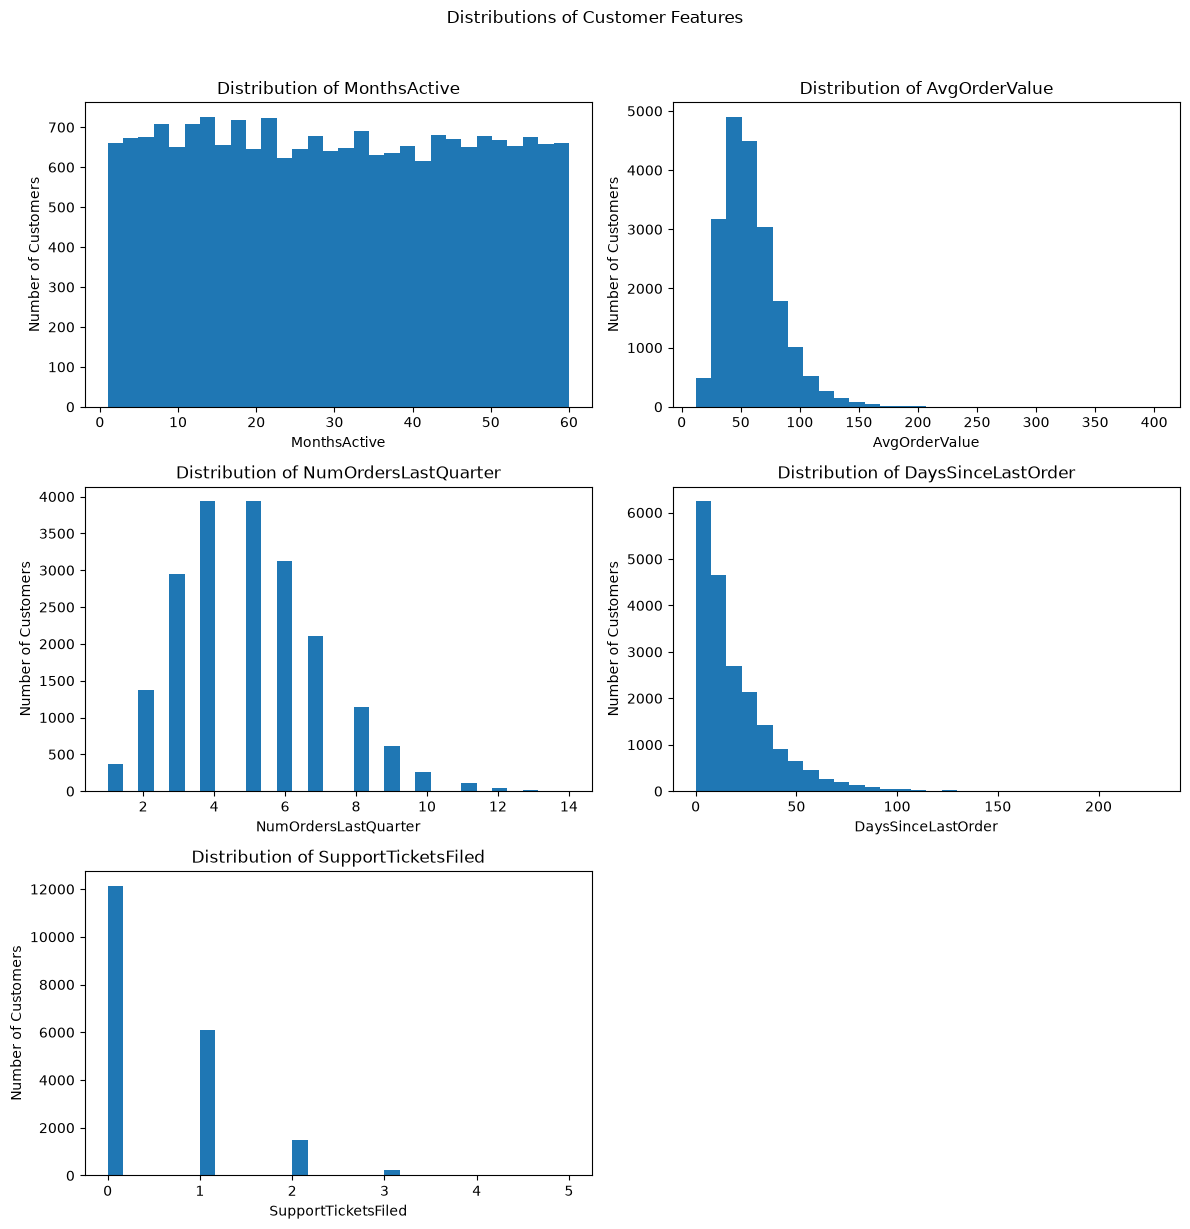

In [148]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for ax, feature in zip(axes.flat, feature_columns):
    ax.hist(data[feature], bins=30)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of Customers')

axes[-1, -1].axis('off')

plt.suptitle('Distributions of Customer Features', y=1.02)
plt.tight_layout()
plt.show()

### 7.10 EDA Findings

The exploratory analysis identified several differences in customer behaviour between churned and non-churned customers.

`DaysSinceLastOrder` shows the clearest relationship with churn. Churn rates increase progressively as the time since the last order increases, with particularly large increases among customers inactive for more than 56 days.

`SupportTicketsFiled` also shows a noticeable pattern. Customers with more support tickets have higher observed churn rates, with the highest group being customers who filed 3 or more tickets.

`NumOrdersLastQuarter` and `MonthsActive` show smaller differences in churn across their behavioural groups, while `AvgOrderValue` displays relatively limited variation.

The distribution analysis also shows non-uniform feature distributions, particularly for `DaysSinceLastOrder` and `AvgOrderValue`, while `SupportTicketsFiled` is concentrated around zero.

These findings describe observed associations in the dataset rather than causal effects. They provide the basis for selecting and preparing features for the classification models.

In [149]:
# Summarise the main differences between churned and non-churned customers

eda_findings = (
    data.groupby('Churned')[feature_columns]
        .mean()
        .T
)

eda_findings.columns = ['Non-churned', 'Churned']

eda_findings['Difference'] = (
    eda_findings['Churned']
    - eda_findings['Non-churned']
)

eda_findings['Percentage Difference'] = (
    (eda_findings['Difference'] / eda_findings['Non-churned']) * 100
).round(2)

eda_findings.round(2)

,Non-churned,Churned,Difference,Percentage Difference
MonthsActive,30.49,27.83,-2.66,-8.73
AvgOrderValue,59.24,58.62,-0.62,-1.05
NumOrdersLastQuarter,5.04,4.68,-0.37,-7.24
DaysSinceLastOrder,17.83,42.13,24.30,136.30
SupportTicketsFiled,0.48,0.73,0.26,54.18


## 8. Data Preparation

Before training the classification models, the dataset must be separated into predictor variables and the target variable. The data will then be divided into training and testing sets so that model performance can be evaluated on customers the models have not seen during training.

### 8.1 Features and Target

The five customer behaviour variables will be used as predictors for the classification models. The `Churned` variable will be used as the binary target that the models will learn to predict.

The behavioural grouping columns created during exploratory analysis are excluded because they were created for analysis rather than being original customer attributes.

In [150]:
# Define the original model features and target

feature_columns = [
    'MonthsActive',
    'AvgOrderValue',
    'NumOrdersLastQuarter',
    'DaysSinceLastOrder',
    'SupportTicketsFiled'
]

X = data[feature_columns].copy()
y = data['Churned'].copy()

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')

print('\nFeatures:')
print(X.columns.tolist())

print('\nTarget distribution:')
display(
    y.value_counts()
     .sort_index()
     .to_frame('Customers')
)

Feature matrix shape: (20000, 5)
Target shape: (20000,)

Features:
['MonthsActive', 'AvgOrderValue', 'NumOrdersLastQuarter', 'DaysSinceLastOrder', 'SupportTicketsFiled']

Target distribution:


,Customers
Churned,
0,18433
1,1567


### 8.2 Feature Engineering

The original customer variables provide useful information about customer behaviour, but relationships between these variables may provide additional signals for churn prediction.

Three behavioural features are created: order activity relative to customer tenure, recency relative to customer tenure, and support interactions relative to recent order activity. These features are derived only from the available customer information and do not use the churn outcome.

In [151]:
# Create additional behavioural features

X_engineered = X.copy()

# Order activity relative to customer tenure
X_engineered['OrdersPerMonthActive'] = (
    X_engineered['NumOrdersLastQuarter'] /
    X_engineered['MonthsActive'].replace(0, np.nan)
)

# Recency relative to customer tenure
X_engineered['RecencyPerMonthActive'] = (
    X_engineered['DaysSinceLastOrder'] /
    X_engineered['MonthsActive'].replace(0, np.nan)
)

# Support tickets relative to recent order activity
X_engineered['TicketsPerOrder'] = (
    X_engineered['SupportTicketsFiled'] /
    X_engineered['NumOrdersLastQuarter'].replace(0, np.nan)
)

# Replace undefined ratios with zero
X_engineered = X_engineered.fillna(0)

model_features = X_engineered.columns.tolist()

print('Model features:')
print(model_features)

print(f'\nTotal model features: {len(model_features)}')

display(X_engineered.head())

Model features:
['MonthsActive', 'AvgOrderValue', 'NumOrdersLastQuarter', 'DaysSinceLastOrder', 'SupportTicketsFiled', 'OrdersPerMonthActive', 'RecencyPerMonthActive', 'TicketsPerOrder']

Total model features: 8


,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,DaysSinceLastOrder,SupportTicketsFiled,OrdersPerMonthActive,RecencyPerMonthActive,TicketsPerOrder
0,7,34.12,7,8,2,1.00,1.14,0.29
1,45,23.38,3,57,1,0.07,1.27,0.33
2,24,94.56,7,37,1,0.29,1.54,0.14
3,39,46.34,7,0,0,0.18,0.00,0.00
4,3,39.04,3,41,2,1.00,13.67,0.67


### 8.3 Train, Validation and Test Split

The engineered feature set is divided into training, validation and test data using a 60/20/20 split.

The training set is used to fit the models, the validation set is used to compare models and make modelling decisions, and the test set remains untouched until the final evaluation.

Stratification is used to preserve the proportion of churned and non-churned customers across all three datasets.

In [152]:
from sklearn.model_selection import train_test_split

# First split: 60% training, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_engineered,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

# Second split: 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print('Dataset split:')
print(f'Training:   {X_train.shape[0]:,} customers')
print(f'Validation: {X_val.shape[0]:,} customers')
print(f'Testing:    {X_test.shape[0]:,} customers')

print('\nTarget distribution by dataset:')

split_summary = pd.DataFrame({
    'Training': y_train.value_counts(),
    'Validation': y_val.value_counts(),
    'Test': y_test.value_counts()
}).sort_index()

split_summary

Dataset split:
Training:   12,000 customers
Validation: 4,000 customers
Testing:    4,000 customers

Target distribution by dataset:


,Training,Validation,Test
Churned,,,
0,11060,3686,3687
1,940,314,313


### 8.4 Handling Class Imbalance

Churn represents only a small proportion of the customer base, making the target variable imbalanced.

The original class distribution will be retained rather than removing non-churned customers or artificially generating observations. Models that support class weighting can assign greater importance to churn cases during training, while model performance will be evaluated using metrics that focus on the minority class.

The validation and test sets will retain the natural class distribution so that model performance reflects the actual customer population.

In [153]:
# Examine the class distribution in the training set

train_class_distribution = (
    y_train.value_counts()
          .sort_index()
          .to_frame('Customers')
)

train_class_distribution['Percentage'] = (
    train_class_distribution['Customers']
    / len(y_train) * 100
).round(2)

train_class_distribution.index = [
    'Non-churned (0)',
    'Churned (1)'
]

train_class_distribution

,Customers,Percentage
Non-churned (0),11060,92.17
Churned (1),940,7.83


### 8.5 Preprocessing and Feature Scaling

The engineered predictors operate on different numerical scales. Standardisation is therefore appropriate for models whose learning process is sensitive to feature magnitude, such as Logistic Regression and K-Nearest Neighbours.

The scaler is fitted only on the training data and then applied to the validation and test sets. This prevents information from the evaluation data from influencing the preprocessing process.

Tree-based models such as Random Forest and Gradient Boosting do not require feature scaling, so they will use the unscaled feature data.

In [154]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the fitted scaler to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Scaled training data shape:', X_train_scaled.shape)
print('Scaled validation data shape:', X_val_scaled.shape)
print('Scaled test data shape:', X_test_scaled.shape)

Scaled training data shape: (12000, 8)
Scaled validation data shape: (4000, 8)
Scaled test data shape: (4000, 8)


## 9. Model Development

Several classification models will be trained to determine how effectively customer behaviour can be used to identify churn.

The models will be trained using the training data, while the validation data will be used later to compare their performance. The test data will remain untouched until the final model has been selected.

### 9.1 Logistic Regression

Logistic Regression is used as the baseline classification model. It provides a relatively simple and interpretable approach for estimating the probability that a customer will churn based on the available features.

Because the model is sensitive to feature scale, the standardised training data will be used. Class weighting is applied to give greater importance to the minority churn class during training.

In [155]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

print('Logistic Regression trained successfully.')

Logistic Regression trained successfully.


### 9.2 Random Forest

Random Forest is an ensemble of decision trees that can capture non-linear relationships and interactions between customer characteristics.

Unlike Logistic Regression, Random Forest does not require feature scaling. Class weighting is applied to account for the imbalance between churned and non-churned customers.

In [156]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print('Random Forest trained successfully.')

Random Forest trained successfully.


### 9.3 Gradient Boosting

Gradient Boosting is another tree-based classification method that builds an ensemble of weak learners sequentially, with each stage attempting to improve the errors of the previous stages.

Like Random Forest, it does not require feature scaling. The model uses the unscaled training features.

Because churn is an imbalanced target, balanced sample weights are used during training so that churned customers receive greater importance than the majority non-churned class.

In [157]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

gradient_boosting_model.fit(
    X_train,
    y_train,
    sample_weight=gradient_boosting_sample_weights
)

print('Gradient Boosting trained successfully with balanced sample weights.')

Gradient Boosting trained successfully with balanced sample weights.


### 9.4 K-Nearest Neighbours

K-Nearest Neighbours (KNN) classifies a customer based on the outcomes of nearby observations in the feature space.

Because KNN is distance-based, the standardised features are used. The training data is balanced through resampling so that the minority churn class receives greater representation during model fitting.

The validation and test sets remain unchanged so that model performance is evaluated on the original customer distribution.

In [158]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample

# Combine the scaled training features and target for balanced resampling
knn_training_data = pd.DataFrame(
    X_train_scaled,
    columns=model_features,
    index=y_train.index
)

knn_training_data['Churned'] = y_train

# Separate the majority and minority classes
knn_majority = knn_training_data[
    knn_training_data['Churned'] == 0
]

knn_minority = knn_training_data[
    knn_training_data['Churned'] == 1
]

# Oversample the minority class to match the majority class size
knn_minority_oversampled = resample(
    knn_minority,
    replace=True,
    n_samples=len(knn_majority),
    random_state=42
)

# Combine the balanced classes
knn_balanced_training_data = pd.concat(
    [knn_majority, knn_minority_oversampled]
).sample(
    frac=1,
    random_state=42
)

# Separate features and target
X_train_knn_balanced = knn_balanced_training_data[
    model_features
]

y_train_knn_balanced = knn_balanced_training_data[
    'Churned'
]

# Train KNN on the balanced training data
knn_model = KNeighborsClassifier(
    n_neighbors=15,
    weights='distance'
)

knn_model.fit(
    X_train_knn_balanced,
    y_train_knn_balanced
)

print('KNN trained successfully with balanced training data.')
print(f'Original training observations: {len(X_train)}')
print(f'Balanced KNN training observations: {len(X_train_knn_balanced)}')
print('\nBalanced training distribution:')
print(y_train_knn_balanced.value_counts().sort_index())

KNN trained successfully with balanced training data.
Original training observations: 12000
Balanced KNN training observations: 22120

Balanced training distribution:
Churned
0    11060
1    11060
Name: count, dtype: int64


## 10. Validation Evaluation

The four trained models will first be evaluated on the validation set. Because churn represents only about 8% of the customer population, accuracy alone would not provide a complete picture of model performance.

A model could achieve high accuracy by predicting that most customers will not churn while still failing to identify many of the customers who actually churn. The evaluation therefore focuses on metrics that measure performance on the churn class as well as overall classification performance.

### 10.1 Why Accuracy Isn't Enough

Accuracy measures the proportion of all predictions that are correct. However, with an imbalanced target, correct predictions for the much larger non-churned class can dominate this measure.

For a churn prediction problem, it is important to examine how well the model identifies actual churners and how reliable its churn predictions are. This makes metrics such as precision, recall and F1-score particularly relevant.

#### Confusion Matrix

A confusion matrix shows how a binary classification model's predictions compare with the actual outcomes.

For this churn problem, the matrix separates predictions into four categories: true negatives, false positives, false negatives and true positives. These outcomes provide the foundation for calculating precision, recall and F1-score and help us understand the types of errors each model makes.

| | **Actual: Non-churned** | **Actual: Churned** |
|---|---:|---:|
| **Predicted: Non-churned** | True Negative (TN) | False Negative (FN) |
| **Predicted: Churned** | False Positive (FP) | True Positive (TP) |

**True Negative (TN):** The model correctly predicts that a customer will not churn.

**False Positive (FP):** The model predicts that a customer will churn, but the customer does not.

**False Negative (FN):** The model predicts that a customer will not churn, but the customer actually churns.

**True Positive (TP):** The model correctly identifies a customer who churns.

### 10.2 Validation Predictions

Each trained model is now used to predict churn on the validation dataset. The validation data was not used during model training, allowing us to assess how the models generalise to unseen customers.

The resulting predictions will be used to calculate the confusion matrices and evaluation metrics for each model.

In [159]:
# Generate validation predictions and probabilities for all models

validation_probabilities = {
    'Logistic Regression': logistic_model.predict_proba(
        X_val_scaled
    )[:, 1],

    'Random Forest': random_forest_model.predict_proba(
        X_val
    )[:, 1],

    'Gradient Boosting': gradient_boosting_model.predict_proba(
        X_val
    )[:, 1],

    'KNN': knn_model.predict_proba(
        pd.DataFrame(
            X_val_scaled,
            columns=model_features,
            index=X_val.index
        )
    )[:, 1]
}

validation_predictions = {
    'Logistic Regression': logistic_model.predict(
        X_val_scaled
    ),

    'Random Forest': random_forest_model.predict(
        X_val
    ),

    'Gradient Boosting': gradient_boosting_model.predict(
        X_val
    ),

    'KNN': knn_model.predict(
        pd.DataFrame(
            X_val_scaled,
            columns=model_features,
            index=X_val.index
        )
    )
}

# NEW: Logistic Regression validation probabilities (used by the top-k, threshold and cost analyses)
logistic_validation_probabilities = validation_probabilities['Logistic Regression']

print('Validation predictions generated successfully.')

for model_name in validation_predictions:
    print(
        f'{model_name}: '
        f'{len(validation_predictions[model_name])} predictions'
    )

Validation predictions generated successfully.
Logistic Regression: 4000 predictions
Random Forest: 4000 predictions
Gradient Boosting: 4000 predictions
KNN: 4000 predictions


### 10.3 Confusion Matrices

The confusion matrices show the types of predictions made by each model on the validation set.

Comparing these matrices allows us to see whether a model is identifying actual churners, how many non-churned customers it incorrectly flags as churners, and how many churners it fails to identify.

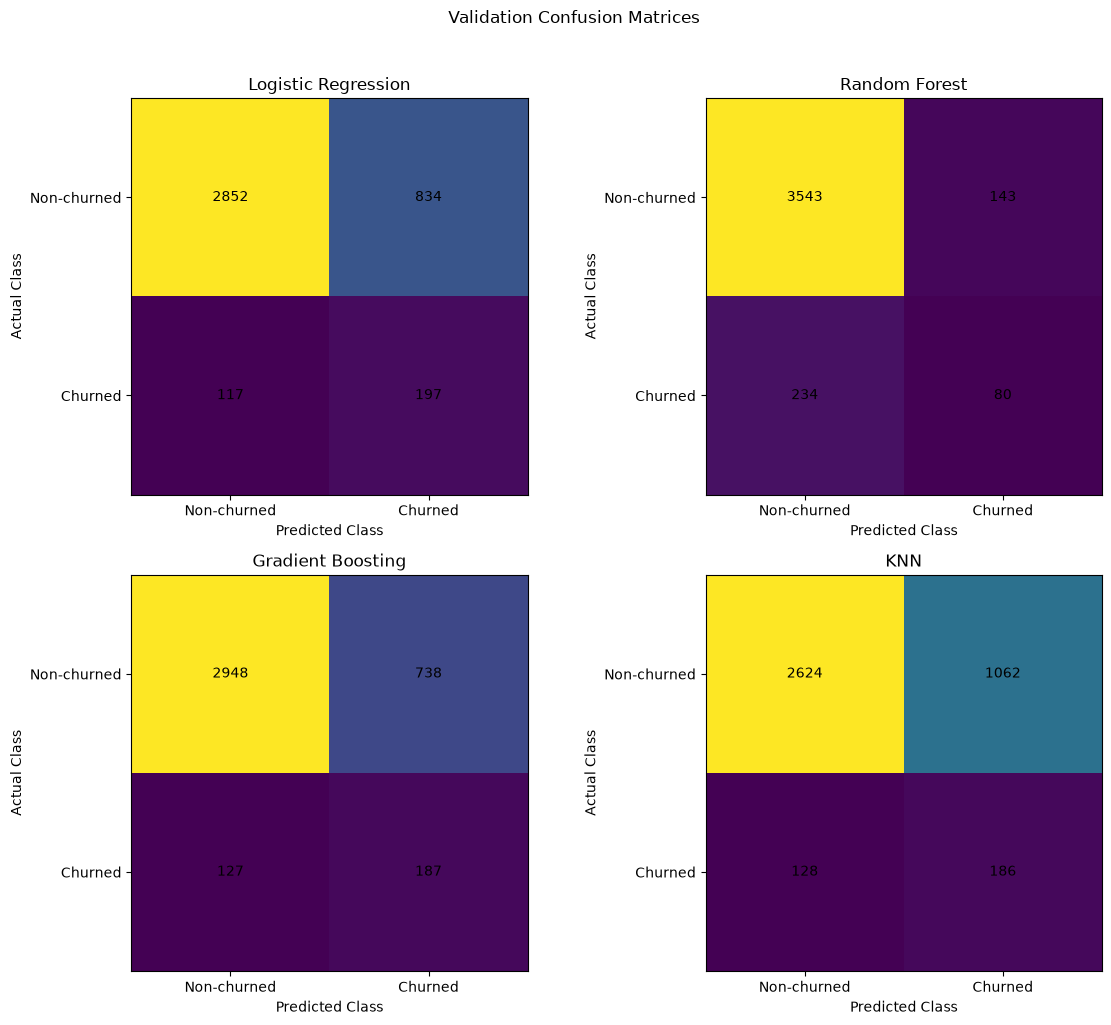

Confusion matrices generated successfully.

Logistic Regression
TN: 2852
FP: 834
FN: 117
TP: 197

Random Forest
TN: 3543
FP: 143
FN: 234
TP: 80

Gradient Boosting
TN: 2948
FP: 738
FN: 127
TP: 187

KNN
TN: 2624
FP: 1062
FN: 128
TP: 186


In [160]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

model_names = [
    'Logistic Regression',
    'Random Forest',
    'Gradient Boosting',
    'KNN'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, model_name in zip(axes.flat, model_names):
    cm = confusion_matrix(
        y_val,
        validation_predictions[model_name]
    )

    ax.imshow(cm)

    ax.set_title(model_name)
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('Actual Class')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Non-churned', 'Churned'])
    ax.set_yticklabels(['Non-churned', 'Churned'])

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )

plt.suptitle(
    'Validation Confusion Matrices',
    y=1.02
)

plt.tight_layout()
plt.show()

print('Confusion matrices generated successfully.')

for model_name in model_names:
    cm = confusion_matrix(
        y_val,
        validation_predictions[model_name]
    )

    tn, fp, fn, tp = cm.ravel()

    print(f'\n{model_name}')
    print(f'TN: {tn}')
    print(f'FP: {fp}')
    print(f'FN: {fn}')
    print(f'TP: {tp}')

### 10.4 Precision, Recall and F1-Score

The confusion matrices show that the models make different trade-offs between identifying churners and avoiding incorrect churn predictions.

We therefore evaluate precision, recall and F1-score for the churn class. Precision measures how often customers predicted as churners actually churn, while recall measures how many of the customers who actually churned were identified. F1-score provides a balance between precision and recall.

In [161]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision_recall_results = []

for model_name in model_names:
    predictions = validation_predictions[model_name]

    precision_recall_results.append({
        'Model': model_name,
        'Precision': precision_score(
            y_val,
            predictions
        ),
        'Recall': recall_score(
            y_val,
            predictions
        ),
        'F1-Score': f1_score(
            y_val,
            predictions
        )
    })

precision_recall_results = pd.DataFrame(
    precision_recall_results
)

precision_recall_results.round(2)

,Model,Precision,Recall,F1-Score
0,Logistic Regression,0.19,0.63,0.29
1,Random Forest,0.36,0.25,0.30
2,Gradient Boosting,0.20,0.60,0.30
3,KNN,0.15,0.59,0.24


### 10.5 Accuracy as a Secondary Metric

Accuracy is included as a secondary evaluation metric to provide context about overall prediction performance.

However, it will not be used in isolation to select the best model because the target is imbalanced. A high accuracy score can coexist with poor identification of the minority churn class.

For context, a baseline that predicts no customer will churn achieves an accuracy of 0.921 on the validation set while identifying no churners. Logistic Regression's lower accuracy of 0.76 therefore reflects a deliberate trade-off in favour of recall, not weaker overall performance.

In [162]:
from sklearn.metrics import accuracy_score

accuracy_results = []

for model_name in model_names:
    predictions = validation_predictions[model_name]

    accuracy_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(
            y_val,
            predictions
        )
    })

accuracy_results = pd.DataFrame(
    accuracy_results
)

accuracy_results.round(2)

,Model,Accuracy
0,Logistic Regression,0.76
1,Random Forest,0.91
2,Gradient Boosting,0.78
3,KNN,0.70


### 10.6 Model Comparison

Precision, recall, F1-score and accuracy depend on the classification threshold used to convert predicted probabilities into class labels.

To compare the models independently of a single threshold, ROC-AUC and PR-AUC are also reported. ROC-AUC measures how well the model separates churners from non-churners across different thresholds, while PR-AUC focuses on the precision-recall trade-off and is particularly informative when the positive class is relatively uncommon.

The threshold-dependent metrics are retained because they show how the models would behave when converted into actual churn predictions.

In [163]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

model_probabilities = {
    'Logistic Regression': validation_probabilities[
        'Logistic Regression'
    ],

    'Random Forest': validation_probabilities[
        'Random Forest'
    ],

    'Gradient Boosting': validation_probabilities[
        'Gradient Boosting'
    ],

    'KNN': validation_probabilities[
        'KNN'
    ]
}

model_predictions = {
    'Logistic Regression': validation_predictions[
        'Logistic Regression'
    ],

    'Random Forest': validation_predictions[
        'Random Forest'
    ],

    'Gradient Boosting': validation_predictions[
        'Gradient Boosting'
    ],

    'KNN': validation_predictions[
        'KNN'
    ]
}

model_comparison = []

for model_name in model_probabilities:

    probabilities = model_probabilities[model_name]
    predictions = model_predictions[model_name]

    model_comparison.append({
        'Model': model_name,

        'ROC-AUC': roc_auc_score(
            y_val,
            probabilities
        ),

        'PR-AUC': average_precision_score(
            y_val,
            probabilities
        ),

        'Precision': precision_score(
            y_val,
            predictions
        ),

        'Recall': recall_score(
            y_val,
            predictions
        ),

        'F1-Score': f1_score(
            y_val,
            predictions
        ),

        'Accuracy': accuracy_score(
            y_val,
            predictions
        )
    })

model_comparison = pd.DataFrame(
    model_comparison
)

model_comparison = (
    model_comparison
    .sort_values(
        by='PR-AUC',
        ascending=False
    )
    .reset_index(drop=True)
)

model_comparison.round(2)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-Score,Accuracy
0,Logistic Regression,0.76,0.34,0.19,0.63,0.29,0.76
1,Gradient Boosting,0.75,0.34,0.20,0.60,0.30,0.78
2,Random Forest,0.72,0.25,0.36,0.25,0.30,0.91
3,KNN,0.70,0.17,0.15,0.59,0.24,0.70


### 10.7 Top-K Risk Ranking and Lift

For a retention team, the model can be used to rank customers by predicted churn probability rather than treating every customer equally.

Top-k analysis evaluates the customers with the highest predicted risk at different intervention capacities. Here, the top 5%, 10% and 20% of customers are examined.

Precision shows the proportion of selected customers who actually churned, recall shows the proportion of all churners captured, and lift compares the churn rate within the selected group with the overall churn rate.

This provides a business-oriented view of how concentrated the churners are among the customers ranked as highest risk.

In [164]:
# Rank validation customers by Logistic Regression churn probability

top_k_data = pd.DataFrame({
    'ActualChurn': y_val.to_numpy(),
    'ChurnProbability': logistic_validation_probabilities
})

top_k_data = top_k_data.sort_values(
    by='ChurnProbability',
    ascending=False
).reset_index(drop=True)

overall_churn_rate = top_k_data['ActualChurn'].mean()

top_k_results = []

for percentage in [0.05, 0.10, 0.20]:
    n_customers = int(len(top_k_data) * percentage)

    selected = top_k_data.head(n_customers)

    precision = selected['ActualChurn'].mean()
    churners_captured = selected['ActualChurn'].sum()
    total_churners = top_k_data['ActualChurn'].sum()
    recall = churners_captured / total_churners
    lift = precision / overall_churn_rate

    top_k_results.append({
        'Top Risk Group': f'Top {int(percentage * 100)}%',
        'Customers Targeted': n_customers,
        'Actual Churners Captured': int(churners_captured),
        'Precision': precision,
        'Recall': recall,
        'Lift': lift
    })

top_k_results = pd.DataFrame(top_k_results)

top_k_results

,Top Risk Group,Customers Targeted,Actual Churners Captured,Precision,Recall,Lift
0,Top 5%,200,87,0.43,0.28,5.54
1,Top 10%,400,124,0.31,0.39,3.95
2,Top 20%,800,173,0.22,0.55,2.75


# Baseline Comparisons

Model performance should be interpreted against simple baselines rather than in isolation.

The first baseline is a majority-class classifier that predicts that no customers will churn. Because churn represents only a small proportion of the dataset, this baseline achieves high accuracy despite identifying no actual churners.

The second baseline uses only `DaysSinceLastOrder` as a predictor. This provides a simple measure of how much predictive information can be obtained from customer recency alone, which was identified as the strongest behavioural signal during exploratory analysis.

Comparing the full models against these baselines helps determine whether the additional modelling complexity provides useful predictive information beyond simple rules.

In [165]:
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

# Majority-class baseline: predict that no customers will churn

majority_baseline_predictions = np.zeros(len(y_val), dtype=int)

majority_baseline_accuracy = accuracy_score(
    y_val,
    majority_baseline_predictions
)

print(f'Majority-class baseline accuracy: {majority_baseline_accuracy:.3f}')

Majority-class baseline accuracy: 0.921


In [166]:
from sklearn.linear_model import LogisticRegression

# Recency-only baseline using DaysSinceLastOrder

recency_feature_train = X_train[['DaysSinceLastOrder']]
recency_feature_val = X_val[['DaysSinceLastOrder']]

recency_scaler = StandardScaler()

recency_train_scaled = recency_scaler.fit_transform(
    recency_feature_train
)

recency_val_scaled = recency_scaler.transform(
    recency_feature_val
)

recency_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

recency_model.fit(
    recency_train_scaled,
    y_train
)

recency_validation_probabilities = recency_model.predict_proba(
    recency_val_scaled
)[:, 1]

recency_validation_predictions = (
    recency_validation_probabilities >= 0.50
).astype(int)

recency_baseline = pd.DataFrame([{
    'Model': 'Recency-only Logistic Regression',
    'ROC-AUC': roc_auc_score(
        y_val,
        recency_validation_probabilities
    ),
    'PR-AUC': average_precision_score(
        y_val,
        recency_validation_probabilities
    ),
    'Precision': precision_score(
        y_val,
        recency_validation_predictions
    ),
    'Recall': recall_score(
        y_val,
        recency_validation_predictions
    ),
    'F1-Score': f1_score(
        y_val,
        recency_validation_predictions
    ),
    'Accuracy': accuracy_score(
        y_val,
        recency_validation_predictions
    )
}])

recency_baseline

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-Score,Accuracy
0,Recency-only Logistic Regression,0.74,0.33,0.19,0.56,0.28,0.77


### 10.8 Evaluating the Impact of Feature Engineering

To determine whether the engineered features improved model performance, the models will be compared using the original features and the engineered feature set on the same validation data.

This comparison helps distinguish between a feature-related limitation and a model or decision-threshold limitation.

In [167]:
# Prepare the original 5-feature validation data
X_train_base = X_train[feature_columns]
X_val_base = X_val[feature_columns]

# Train a baseline Logistic Regression using only the original features
logistic_baseline = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

logistic_baseline.fit(
    StandardScaler().fit_transform(X_train_base),
    y_train
)

# Scale validation data using the training scaler
baseline_scaler = StandardScaler()
X_train_base_scaled = baseline_scaler.fit_transform(X_train_base)
X_val_base_scaled = baseline_scaler.transform(X_val_base)

# Refit using the correctly scaled training data
logistic_baseline.fit(X_train_base_scaled, y_train)

# Generate validation predictions
baseline_predictions = logistic_baseline.predict(X_val_base_scaled)

# Calculate metrics
baseline_metrics = {
    'Precision': precision_score(y_val, baseline_predictions),
    'Recall': recall_score(y_val, baseline_predictions),
    'F1-Score': f1_score(y_val, baseline_predictions),
    'Accuracy': accuracy_score(y_val, baseline_predictions)
}

# FIXED: reads from model_comparison (cell 79) instead of the old validation_metrics
engineered_metrics = model_comparison[
    model_comparison['Model'] == 'Logistic Regression'
].iloc[0]

comparison = pd.DataFrame({
    'Original 5 Features': baseline_metrics,
    'Engineered 8 Features': {
        'Precision': engineered_metrics['Precision'],
        'Recall': engineered_metrics['Recall'],
        'F1-Score': engineered_metrics['F1-Score'],
        'Accuracy': engineered_metrics['Accuracy']
    }
})

comparison

,Original 5 Features,Engineered 8 Features
Precision,0.19,0.19
Recall,0.63,0.63
F1-Score,0.29,0.29
Accuracy,0.76,0.76


### 10.9 Final Model Performance Across Splits

The training and validation results are used to compare model behaviour and assess generalisation during model development.

The test set is reserved as a final holdout and is evaluated only after the model and classification approach have been selected. This prevents repeated use of the test set from influencing model selection.

The final test evaluation will therefore focus on the selected Logistic Regression model.

In [168]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Store models and their corresponding train/validation datasets
model_evaluation_data = {
    'Logistic Regression': {
        'model': logistic_model,
        'X_train': X_train_scaled,
        'X_val': X_val_scaled
    },

    'Random Forest': {
        'model': random_forest_model,
        'X_train': X_train,
        'X_val': X_val
    },

    'Gradient Boosting': {
        'model': gradient_boosting_model,
        'X_train': X_train,
        'X_val': X_val
    },

    'KNN': {
        'model': knn_model,
        'X_train': pd.DataFrame(
            X_train_scaled,
            columns=model_features,
            index=X_train.index
        ),
        'X_val': pd.DataFrame(
            X_val_scaled,
            columns=model_features,
            index=X_val.index
        )
    }
}

split_results = []

for model_name, model_info in model_evaluation_data.items():

    model = model_info['model']

    train_predictions = model.predict(
        model_info['X_train']
    )

    validation_predictions_current = model.predict(
        model_info['X_val']
    )

    split_results.append({
        'Model': model_name,
        'Split': 'Train',
        'Precision': precision_score(
            y_train,
            train_predictions
        ),
        'Recall': recall_score(
            y_train,
            train_predictions
        ),
        'F1-Score': f1_score(
            y_train,
            train_predictions
        ),
        'Accuracy': accuracy_score(
            y_train,
            train_predictions
        )
    })

    split_results.append({
        'Model': model_name,
        'Split': 'Validation',
        'Precision': precision_score(
            y_val,
            validation_predictions_current
        ),
        'Recall': recall_score(
            y_val,
            validation_predictions_current
        ),
        'F1-Score': f1_score(
            y_val,
            validation_predictions_current
        ),
        'Accuracy': accuracy_score(
            y_val,
            validation_predictions_current
        )
    })

split_results = pd.DataFrame(split_results)

split_results.round(2)

,Model,Split,Precision,Recall,F1-Score,Accuracy
0,Logistic Regression,Train,0.19,0.65,0.30,0.76
1,Logistic Regression,Validation,0.19,0.63,0.29,0.76
2,Random Forest,Train,0.98,1.00,0.99,1.00
3,Random Forest,Validation,0.36,0.25,0.30,0.91
4,Gradient Boosting,Train,0.22,0.72,0.34,0.78
5,Gradient Boosting,Validation,0.20,0.60,0.30,0.78
6,KNN,Train,1.00,1.00,1.00,1.00
7,KNN,Validation,0.15,0.59,0.24,0.70


#### Final Test Evaluation

The test set is now evaluated as a final holdout using the selected Logistic Regression model. This result is used to report how the selected model performs on previously unseen data.

In [169]:
# Final evaluation of the selected model on the untouched test set

logistic_test_predictions = logistic_model.predict(X_test_scaled)

final_test_metrics = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Split': 'Test',
    'Precision': precision_score(y_test, logistic_test_predictions),
    'Recall': recall_score(y_test, logistic_test_predictions),
    'F1-Score': f1_score(y_test, logistic_test_predictions),
    'Accuracy': accuracy_score(y_test, logistic_test_predictions)
}])

final_test_metrics

,Model,Split,Precision,Recall,F1-Score,Accuracy
0,Logistic Regression,Test,0.19,0.62,0.29,0.76


### 10.10 Interpret Model Behaviour

The model results show different patterns of generalisation and predictive behaviour.

Logistic Regression produces similar training and validation performance, with an F1-score of 0.30 on the training set and 0.29 on validation. This indicates relatively stable generalisation.

Gradient Boosting also shows a relatively small difference between training and validation performance. Its F1-score decreases from 0.34 on training data to 0.30 on validation data after balanced sample weighting.

Random Forest shows a much larger gap between training and validation performance. Its training F1-score is 0.99 compared with 0.30 on validation, indicating that the model fits the training data very closely but does not maintain the same performance on unseen validation observations.

KNN also shows a large generalisation gap. Its balanced training F1-score is 1.00, while validation F1-score is 0.24. Although balancing substantially increased its validation recall, this came with lower precision and did not translate into stronger overall validation performance.

These results indicate that training performance alone is not sufficient for judging model quality. Validation performance provides a more useful indication of how the models behave on unseen customers.

In [170]:
# Extract Logistic Regression coefficients
logistic_coefficients = pd.DataFrame({
    'Feature': model_features,
    'Coefficient': logistic_model.coef_[0]
})

logistic_coefficients['AbsoluteCoefficient'] = (
    logistic_coefficients['Coefficient'].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    by='AbsoluteCoefficient',
    ascending=False
).drop(columns='AbsoluteCoefficient')

logistic_coefficients.reset_index(drop=True)

,Feature,Coefficient
0,DaysSinceLastOrder,0.86
1,SupportTicketsFiled,0.46
2,NumOrdersLastQuarter,-0.26
3,MonthsActive,-0.22
4,OrdersPerMonthActive,-0.12
5,RecencyPerMonthActive,0.05
6,AvgOrderValue,-0.03
7,TicketsPerOrder,-0.01


The Logistic Regression coefficients show that DaysSinceLastOrder has the strongest positive contribution to churn predictions, followed by SupportTicketsFiled. NumOrdersLastQuarter and MonthsActive have negative coefficients, indicating that higher recent order activity and longer customer activity are associated with lower predicted churn.

These results are consistent with the exploratory analysis, where DaysSinceLastOrder showed the clearest relationship with churn. The agreement between the exploratory findings and model coefficients provides additional evidence that customer recency is an important signal for identifying potential churn.

The coefficients represent associations used by the model and should not be interpreted as evidence of causation.

### 10.11 Classification Threshold & Precision–Recall Trade-off

The default classification threshold of 0.50 is not necessarily the most appropriate threshold for a churn intervention workflow.

Changing the threshold changes the balance between precision and recall. A lower threshold identifies more potential churners, increasing recall, but also increases the number of non-churned customers incorrectly flagged. A higher threshold reduces the number of customers flagged, improving precision, but may cause more actual churners to be missed.

The following analysis evaluates several thresholds using the Logistic Regression validation probabilities. The purpose is to show the operational trade-off rather than select a threshold based only on a mathematical metric.

The final threshold should therefore be determined using the business cost of contacting a customer compared with the expected value of successfully retaining a customer.

In [171]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

logistic_validation_probabilities = validation_probabilities[
    'Logistic Regression'
]

thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

threshold_results = []

for threshold in thresholds:

    threshold_predictions = (
        logistic_validation_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': threshold,

        'Precision': precision_score(
            y_val,
            threshold_predictions
        ),

        'Recall': recall_score(
            y_val,
            threshold_predictions
        ),

        'F1-Score': f1_score(
            y_val,
            threshold_predictions
        ),

        'Accuracy': accuracy_score(
            y_val,
            threshold_predictions
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(2)

,Threshold,Precision,Recall,F1-Score,Accuracy
0,0.20,0.09,0.94,0.16,0.25
1,0.30,0.11,0.85,0.20,0.47
2,0.40,0.15,0.73,0.25,0.66
3,0.50,0.19,0.63,0.29,0.76
4,0.60,0.24,0.51,0.32,0.83
5,0.70,0.31,0.39,0.35,0.88
6,0.80,0.43,0.28,0.34,0.91


In [172]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []

for threshold in thresholds:
    threshold_predictions = (
        logistic_validation_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_val, threshold_predictions),
        'Recall': recall_score(y_val, threshold_predictions),
        'F1-Score': f1_score(y_val, threshold_predictions),
        'Accuracy': accuracy_score(y_val, threshold_predictions)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1-Score,Accuracy
0,0.20,0.09,0.94,0.16,0.25
1,0.30,0.11,0.85,0.20,0.47
2,0.40,0.15,0.73,0.25,0.66
3,0.50,0.19,0.63,0.29,0.76
4,0.60,0.24,0.51,0.32,0.83
5,0.70,0.31,0.39,0.35,0.88
6,0.80,0.43,0.28,0.34,0.91


The threshold analysis demonstrates a clear precision–recall trade-off. Lower thresholds identify more potential churners, increasing recall but also producing more false positives. Higher thresholds produce more precise churn predictions but miss a greater proportion of actual churners.

Within the thresholds tested, the F1-score increased from 0.16 at a threshold of 0.20 to 0.35 at 0.70 before slightly decreasing to 0.34 at 0.80. However, the threshold should not be selected solely from these validation results. The appropriate threshold ultimately depends on the business cost of missing a potential churner compared with contacting a customer who would not have churned.

#### Cost-Based Threshold View

The threshold analysis above shows the precision–recall trade-off, but the appropriate threshold depends on the economics of the retention programme. Three business inputs are needed:

- **Contact cost:** the cost of making one retention contact.
- **Customer value:** the value of retaining one customer.
- **Save rate:** the proportion of contacted churners the retention action actually retains.

A flagged customer is only worth contacting if the model's precision at the chosen threshold exceeds the breakeven precision, calculated as contact cost ÷ (save rate × customer value).

The values below are **placeholder assumptions** and must be replaced with the business's own figures. The analysis uses the validation set only, so the test set remains untouched.

In [173]:
# ---- BUSINESS ASSUMPTIONS (placeholders: replace with real figures) ----
contact_cost = 5        # cost of one retention contact, per customer
customer_value = 100    # value of retaining one customer
save_rate = 0.30        # share of contacted churners the action retains

breakeven_precision = contact_cost / (save_rate * customer_value)
print(f'Breakeven precision: {breakeven_precision:.1%}')

cost_thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
y_val_array = y_val.to_numpy()

cost_results = []

for threshold in cost_thresholds:
    flagged_mask = logistic_validation_probabilities >= threshold

    flagged = int(flagged_mask.sum())
    true_positives = int((flagged_mask & (y_val_array == 1)).sum())
    false_positives = flagged - true_positives

    customers_saved = true_positives * save_rate
    total_cost = flagged * contact_cost
    total_benefit = customers_saved * customer_value

    cost_results.append({
        'Threshold': threshold,
        'Customers Flagged': flagged,
        'Churners Reached': true_positives,
        'False Alarms': false_positives,
        'Precision': true_positives / flagged,
        'Contact Cost': total_cost,
        'Benefit': total_benefit,
        'Net Value': total_benefit - total_cost
    })

cost_results = pd.DataFrame(cost_results)

best_row = cost_results.loc[cost_results['Net Value'].idxmax()]
print(
    f"Highest net value at threshold {best_row['Threshold']:.2f}: "
    f"{best_row['Net Value']:,.0f}"
)

cost_results.round(2)

Breakeven precision: 16.7%
Highest net value at threshold 0.70: 1,725


,Threshold,Customers Flagged,Churners Reached,False Alarms,Precision,Contact Cost,Benefit,Net Value
0,0.20,3279,295,2984,0.09,16395,"8,850.00","-7,545.00"
1,0.30,2333,267,2066,0.11,11665,"8,010.00","-3,655.00"
2,0.40,1520,230,1290,0.15,7600,"6,900.00",-700.00
3,0.50,1031,197,834,0.19,5155,"5,910.00",755.00
4,0.60,673,160,513,0.24,3365,"4,800.00","1,435.00"
5,0.70,399,124,275,0.31,1995,"3,720.00","1,725.00"
6,0.80,208,89,119,0.43,1040,"2,670.00","1,630.00"


Using placeholder assumptions of a contact cost of 5, a customer value of 100 and a save rate of 30%, the breakeven precision is 16.7%. Net value is highest at a threshold of 0.70, where the model flags 399 customers, reaches 124 churners, and produces a net value of 1,725 on the validation set.

The default 0.50 threshold is not necessarily the most profitable choice, because the best threshold depends on these business inputs rather than on the model alone. These figures are illustrative estimates based on validation data and should be revisited once real contact costs and retention outcomes are available.

### 10.12 Evaluation Conclusion

The validation results show that accuracy alone is not sufficient for evaluating the churn models because churn is a minority class in the dataset.

Logistic Regression achieved a ROC-AUC of 0.76 and PR-AUC of 0.34, with a recall of 0.63 and an F1-score of 0.29 at the default 0.50 classification threshold. Its training and validation results were also closely aligned, indicating stable generalisation.

Gradient Boosting achieved a ROC-AUC of 0.75 and PR-AUC of 0.34, with a recall of 0.60 and an F1-score of 0.30 after balanced sample weighting. Its training and validation performance was also relatively consistent.

Random Forest achieved higher precision of 0.36 and an F1-score of 0.30, but its recall was only 0.25. Its training F1-score of 0.99 compared with 0.30 on validation also indicates a substantial generalisation gap.

KNN achieved a validation recall of 0.59 after minority-class oversampling, but its precision was 0.15 and PR-AUC was 0.17. Its training F1-score of 1.00 compared with 0.24 on validation indicates a substantial generalisation gap.

The results therefore show that the models offer different trade-offs between identifying churners and limiting false positives. Logistic Regression provides strong recall and the highest ROC-AUC while maintaining stable performance between training and validation data. Gradient Boosting provides a similar PR-AUC and slightly higher F1-score, while Random Forest provides higher precision but identifies fewer churners.

The threshold analysis also demonstrates that changing the Logistic Regression classification threshold changes the balance between precision and recall. The appropriate threshold should therefore depend on the intended business use and the relative cost of false positives and false negatives.

Overall, model selection should consider predictive performance, generalisation, interpretability, and the operational purpose of the churn model rather than relying on accuracy alone.

## 11. What Did We Discover?

The analysis identified several behavioural patterns associated with customer churn. These findings combine the exploratory analysis, customer behaviour groups, and the final classification model results to describe which characteristics provide the strongest signals of potential churn. 

### 11.1 Customer Recency as a Churn Signal

`DaysSinceLastOrder` was the clearest behavioural signal associated with customer churn. Customers with longer periods since their last order showed substantially higher observed churn rates.

Across the recency groups examined during exploratory analysis, the churn rate rose steadily from 3.20% among customers who ordered within the last 7 days to 6.58% at 22–28 days and 15.58% at 43–56 days. Beyond that point the increase became much steeper: 34.16% at 57–84 days and 67.31% at 85 or more days. Churn risk therefore accelerates sharply once a customer has been inactive for roughly two months.

The Logistic Regression model also assigned the largest positive coefficient to `DaysSinceLastOrder`. The recency-only baseline achieved a ROC-AUC of 0.74 and PR-AUC of 0.33, compared with 0.76 and 0.34 for the full Logistic Regression model. This indicates that customer recency alone contains most of the predictive information available in the dataset.

Together, these findings suggest that increasing customer inactivity is an important indicator of potential churn risk.

### 11.2 Customer Support Activity

`SupportTicketsFiled` was the second strongest positive coefficient in the Logistic Regression model. Customers with higher support-ticket activity also showed higher observed churn rates in the exploratory analysis.

Churn increased steadily with the number of tickets filed: 6.11% among customers with no tickets, 9.23% with one ticket, 14.01% with two tickets, and 19.64% with three or more.

This suggests that support activity may provide an additional signal of customer risk, particularly when considered alongside customer recency and ordering behaviour.

However, the relationship is weaker than the pattern observed for `DaysSinceLastOrder`, so support activity should be treated as a secondary indicator rather than a standalone churn signal.

### 11.3 Customer Engagement and Activity

`NumOrdersLastQuarter` and `MonthsActive` showed negative relationships with predicted churn in the Logistic Regression model. The exploratory analysis also showed generally lower churn rates across higher levels of recent ordering activity and customer engagement.

`NumOrdersLastQuarter` had a negative Logistic Regression coefficient, while `MonthsActive` also had a negative coefficient. These relationships suggest that customers with greater recent activity and longer engagement may exhibit lower observed churn risk in this dataset.

However, these relationships were considerably weaker than the pattern observed for `DaysSinceLastOrder`.

`AvgOrderValue` showed only a weak relationship with churn, indicating that customer spending per order provides less information about churn than behavioural measures of activity and recency.

### 11.4 Overall Churn Pattern

The overall analysis suggests that churn in this dataset is more closely associated with customer engagement and recency behaviour than with customer spending alone.

`DaysSinceLastOrder` provided the strongest behavioural signal, while `SupportTicketsFiled` provided a secondary indication of potential churn risk. Ordering activity and tenure showed weaker negative relationships with churn, while `AvgOrderValue` showed limited variation in churn across customer groups.

The modelling results support this pattern. Logistic Regression achieved a validation ROC-AUC of 0.76 and PR-AUC of 0.34, while the recency-only baseline achieved a ROC-AUC of 0.74 and PR-AUC of 0.33. This indicates that recency explains a substantial part of the predictive signal, while the additional customer features provide some additional information.

The risk-ranking analysis also showed that churners were concentrated among customers assigned higher predicted risk. Among the top 5% of customers ranked by Logistic Regression risk, 28% of all validation churners were captured, with a lift of 5.54 compared with the overall churn rate.

These findings suggest that monitoring changes in customer activity and recency can provide a practical basis for identifying customers who may require closer attention, rather than relying on transaction value alone.

## 12. Business Decision

The findings can support a proactive customer-retention workflow. Rather than waiting until customers have already churned, the business can use customer behaviour and predicted churn risk to identify customers who may require attention.

The analysis indicates that customer inactivity is the clearest observed signal of churn, while support-ticket activity provides an additional indicator. These signals can therefore be incorporated into a workflow that prioritises customers for retention review.

### 12.1 Using Churn Risk for Retention

The selected churn model can assign each customer a predicted probability of churn. Customers can then be ranked according to predicted risk rather than treating the entire customer base as having the same likelihood of churn.

This allows a retention team to focus limited resources on customers with higher predicted risk.

The validation top-k analysis demonstrates this potential. Among the top 5% of customers ranked by Logistic Regression risk, 87 of the 200 customers were actual churners, giving a precision of 0.43 and capturing 28% of all churners in the validation set.

The business can therefore use risk ranking to define an intervention group based on its available retention capacity.

### 12.2 Recommended Business Workflow

A practical churn-management workflow would be:

1. **Collect customer behaviour data** such as recent ordering activity, days since the last order, customer tenure, order value, and support-ticket activity.

2. **Generate churn-risk predictions** using the selected classification model.

3. **Rank customers by predicted risk** so that the highest-risk customers can be reviewed first.

4. **Review customer context** before taking action. A high predicted risk should be treated as a signal for investigation rather than proof that a customer will churn.

5. **Apply an appropriate retention action**, such as a customer-service follow-up, engagement message, or other retention intervention selected by the business.

6. **Monitor the outcome** to determine whether the intervention reduces subsequent churn and whether the model continues to identify useful customer segments.

### 12.3 Business Use and Limitation

The model should be used as a decision-support tool rather than as an automatic decision-maker. A predicted churn probability indicates estimated risk based on the patterns learned from the available customer data; it does not establish that a customer will definitely churn.

The classification threshold should also be aligned with the business's available intervention capacity and the relative costs of false positives and false negatives. The threshold analysis showed that lower thresholds capture more potential churners but also flag more non-churned customers, while higher thresholds reduce the number of customers flagged but miss more churners.

An important limitation concerns the timing of `DaysSinceLastOrder` relative to the churn label. If the recency measurement was recorded after, or very close to, the event used to define churn, its strong predictive relationship may partly reflect information that would not have been available early enough for a real retention intervention. In a production system, the business should define a clear prediction date and ensure that only information available before that date is used to generate the churn prediction.

The observed relationships are also associations rather than evidence that inactivity or support-ticket activity directly causes churn. Retention actions should therefore be evaluated using subsequent customer outcomes rather than assuming that changing a particular behaviour will necessarily prevent churn.

## 13. Final Model Recommendation

Based on the validation results, Logistic Regression is selected as the final model for the customer churn use case.

The selection is based on the combination of predictive performance, generalisation, interpretability, and suitability for a customer-retention workflow.

Logistic Regression achieved a validation ROC-AUC of 0.76 and PR-AUC of 0.34, with a recall of 0.63 and an F1-score of 0.29 at the default classification threshold. Its training and validation performance was also closely aligned, with F1-scores of 0.30 and 0.29 respectively.

Gradient Boosting produced a similar validation PR-AUC of 0.34 and an F1-score of 0.30, with recall of 0.60. However, Logistic Regression achieved slightly higher ROC-AUC and recall while providing a more directly interpretable relationship between the input features and predicted churn risk.

Random Forest achieved higher precision of 0.36 but identified substantially fewer churners, with recall of 0.25. It also showed a large training-to-validation performance gap.

KNN achieved recall of 0.59 after minority-class oversampling, but its precision was 0.15 and PR-AUC was 0.17. Its training F1-score of 1.00 compared with 0.24 on validation also indicates a substantial generalisation gap.

Logistic Regression therefore provides a practical balance between identifying potential churners, maintaining stable performance on unseen validation data, and providing interpretable model behaviour.

At the default 0.50 threshold, the model achieves approximately 19% precision and 63% recall. This means that the model identifies a substantial proportion of actual churners, but a significant number of flagged customers will not ultimately churn. The model should therefore be used to prioritise customers for review rather than as a definitive churn decision.

At this threshold the model flags roughly one in four customers as at risk (about 26% of the validation set), and about 81% of those flagged do not go on to churn. Its accuracy of 0.76 is also lower than the 0.92 achieved by a baseline that predicts no customer will churn. This is an expected consequence of prioritising the identification of churners over overall accuracy, and it is why accuracy was not used to select the model.

The classification threshold should be determined separately according to the business's retention capacity, intervention cost, and the value of successfully retaining a customer. The threshold analysis demonstrated that changing the threshold can substantially alter the balance between precision and recall.

The final test evaluation produced a precision of 0.19, recall of 0.62, F1-score of 0.29, accuracy of 0.76, ROC-AUC of 0.76, and PR-AUC of 0.31. These results are broadly consistent with the validation results, indicating that the selected model maintains similar performance on the unseen test set.

The final model can therefore be used as a churn-risk decision-support tool, with the classification threshold determined according to the business's intervention capacity and the relative cost of false positives and false negatives.

## Final Test Evaluation

After selecting Logistic Regression using the training and validation results, the untouched test set is used for the final evaluation.

The test set was not used during model selection or threshold analysis. This provides a final estimate of how the selected model performs on unseen customer observations.

The evaluation reports precision, recall, F1-score, accuracy, ROC-AUC, and PR-AUC so that performance on the minority churn class is assessed alongside overall classification performance.

In [174]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)

# Generate final test predictions and probabilities
logistic_test_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

logistic_test_predictions = logistic_model.predict(
    X_test_scaled
)

# Calculate confusion matrix
test_confusion_matrix = confusion_matrix(
    y_test,
    logistic_test_predictions
)

tn, fp, fn, tp = test_confusion_matrix.ravel()

# Calculate final test metrics
final_test_results = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Precision': precision_score(
        y_test,
        logistic_test_predictions
    ),
    'Recall': recall_score(
        y_test,
        logistic_test_predictions
    ),
    'F1-Score': f1_score(
        y_test,
        logistic_test_predictions
    ),
    'Accuracy': accuracy_score(
        y_test,
        logistic_test_predictions
    ),
    'ROC-AUC': roc_auc_score(
        y_test,
        logistic_test_probabilities
    ),
    'PR-AUC': average_precision_score(
        y_test,
        logistic_test_probabilities
    )
}])

print('Final Test Confusion Matrix')
print(
    f'TN: {tn}'
)
print(
    f'FP: {fp}'
)
print(
    f'FN: {fn}'
)
print(
    f'TP: {tp}'
)

print('\nFinal Test Performance')
display(final_test_results.round(2))

Final Test Confusion Matrix
TN: 2839
FP: 848
FN: 118
TP: 195

Final Test Performance


,Model,Precision,Recall,F1-Score,Accuracy,ROC-AUC,PR-AUC
0,Logistic Regression,0.19,0.62,0.29,0.76,0.76,0.31
